In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
df =pd.read_csv("accident_prediction_india.csv")

In [ ]:
display(df.head())

# 1. Check for missing data
print("Missing Data Check:")
print(df.isnull().sum())

# 2. Clean the data by dropping empty rows
df = df.dropna()

,State Name,City Name,Year,Month,Day of Week,Time of Day,Accident Severity,Number of Vehicles Involved,Vehicle Type Involved,Number of Casualties,...,Road Type,Road Condition,Lighting Conditions,Traffic Control Presence,Speed Limit (km/h),Driver Age,Driver Gender,Driver License Status,Alcohol Involvement,Accident Location Details
0,Jammu and Kashmir,Unknown,2021,May,Monday,1:46,Serious,5,Cycle,0,...,National Highway,Wet,Dark,Signs,61,66,Male,NaN,Yes,Curve
1,Uttar Pradesh,Lucknow,2018,January,Wednesday,21:30,Minor,5,Truck,5,...,Urban Road,Dry,Dusk,Signs,92,60,Male,NaN,Yes,Straight Road
2,Chhattisgarh,Unknown,2023,May,Wednesday,5:37,Minor,5,Pedestrian,6,...,National Highway,Under Construction,Dawn,Signs,120,26,Female,NaN,No,Bridge
3,Uttar Pradesh,Lucknow,2020,June,Saturday,0:31,Minor,3,Bus,10,...,State Highway,Dry,Dark,Signals,76,34,Female,Valid,Yes,Straight Road
4,Sikkim,Unknown,2021,August,Thursday,11:21,Minor,5,Cycle,7,...,Urban Road,Wet,Dusk,Signs,115,30,Male,NaN,No,Intersection


Missing Data Check:
State Name                       0
City Name                        0
Year                             0
Month                            0
Day of Week                      0
Time of Day                      0
Accident Severity                0
Number of Vehicles Involved      0
Vehicle Type Involved            0
Number of Casualties             0
Number of Fatalities             0
Weather Conditions               0
Road Type                        0
Road Condition                   0
Lighting Conditions              0
Traffic Control Presence       716
Speed Limit (km/h)               0
Driver Age                       0
Driver Gender                    0
Driver License Status          975
Alcohol Involvement              0
Accident Location Details        0
dtype: int64


In [ ]:
#  Extracting the top 5 states with the highest frequency of accidents
top_states = df['State Name'].value_counts().head(5)

print("Top 5 Most Dangerous States:")
print(top_states)

Top 5 Most Dangerous States:
State Name
Uttarakhand    59
Karnataka      57
Puducherry     56
Goa            55
Haryana        55
Name: count, dtype: int64


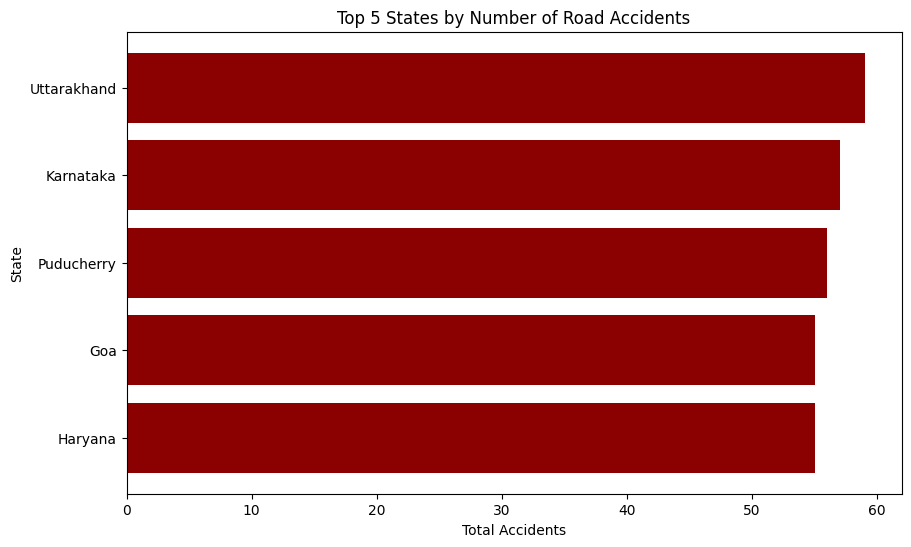

In [ ]:
# 1. Set the size of the chart so it isn't squished
plt.figure(figsize=(10, 6))

# 2. Create a horizontal bar chart
plt.barh(top_states.index, top_states.values, color='darkred')

# 3. Formatting chart axes and title for readability
plt.title('Top 5 States by Number of Road Accidents')
plt.xlabel('Total Accidents')
plt.ylabel('State')

# 4. Put the highest number at the top of the chart
plt.gca().invert_yaxis()

# 5. Show the final image
plt.show()

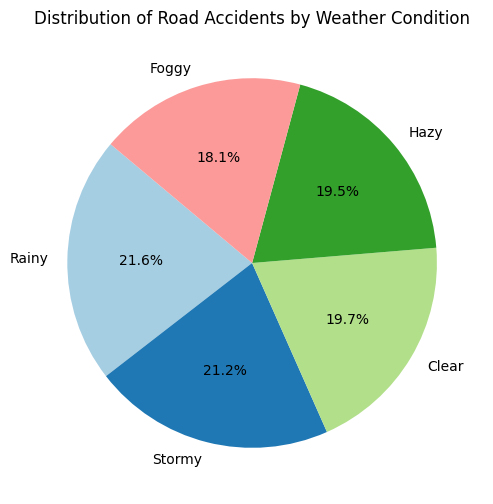

In [26]:
# Grouping the dataset by weather conditions to analyze environmental factors
weather_counts = df['Weather Conditions'].value_counts()

# Generating a pie chart to show the percentage distribution
plt.figure(figsize=(8, 6))
plt.pie(weather_counts.values, labels=weather_counts.index, autopct='%1.1f%%', startangle=140, colors=plt.cm.Paired.colors)

# Adding the title
plt.title('Distribution of Road Accidents by Weather Condition')

# Displaying the chart
plt.show()

The weather distribution analysis reveals that a significant portion of accidents occur during adverse weather conditions, specifically Rainy (21.6%) and Stormy (21.2%) environments. This indicates that visibility and road traction are major contributing factors to accident severity

### Yearly Trend Analysis
We will examine how the number of accidents has changed over the years to identify long-term trends.

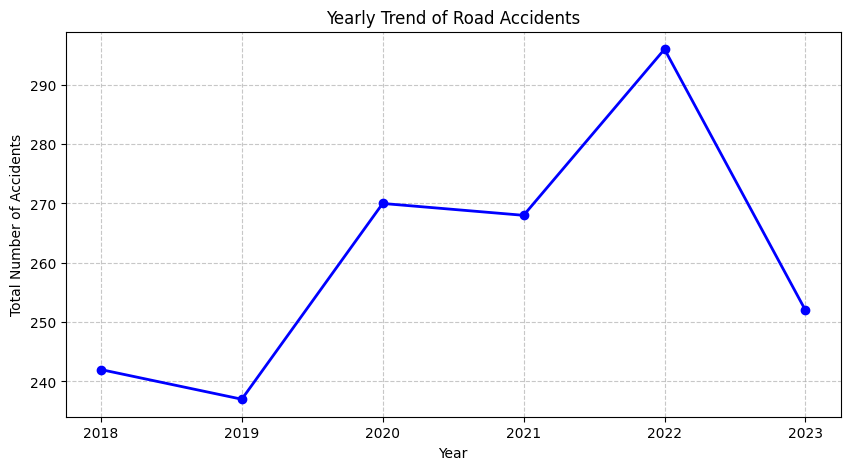

In [ ]:
# 1. Grouping accidents by Year
yearly_trend = df.groupby('Year').size()

# 2. Creating a line plot to show the trend
plt.figure(figsize=(10, 5))
plt.plot(yearly_trend.index, yearly_trend.values, marker='o', linestyle='-', color='blue', linewidth=2)

# 3. Customizing the plot for clear communication
plt.title('Yearly Trend of Road Accidents')
plt.xlabel('Year')
plt.ylabel('Total Number of Accidents')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(yearly_trend.index) # Ensure every year is shown

plt.show()

The yearly trend reveals a highly fluctuating pattern. There were significant spikes in road accidents during 2020 and 2022, followed by a sharp decline in 2023. This suggests that external factors during those peak years heavily impacted road safety.

#Impact of alcohol consumption on Road accidents

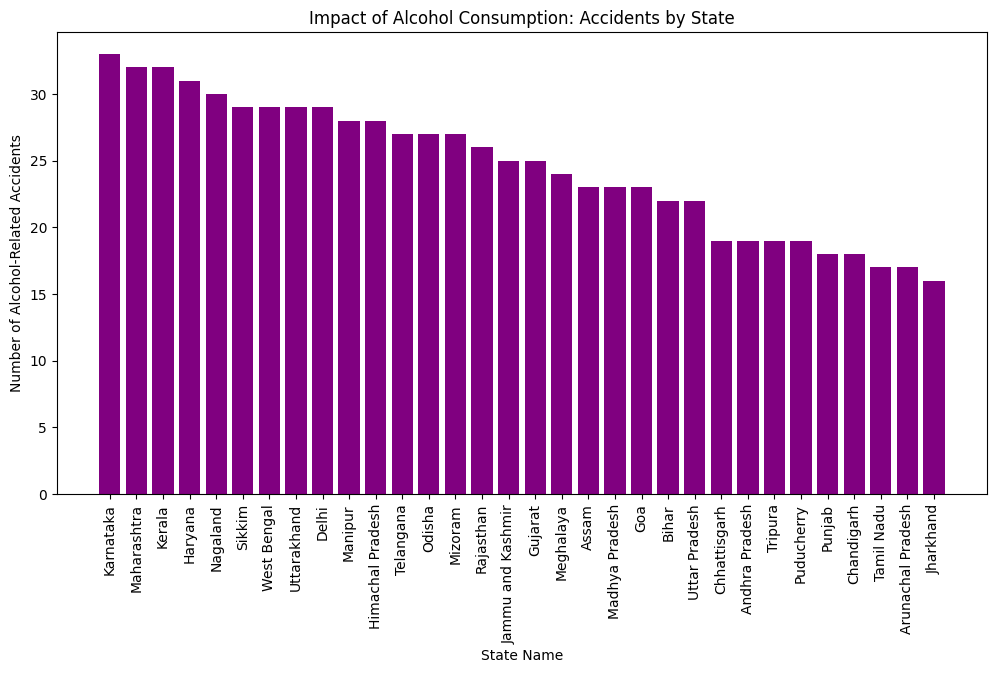

In [27]:
# 1. Filter the dataset to ONLY look at rows where alcohol was involved
alcohol_df = df[df['Alcohol Involvement'] == 'Yes']

# 2. Group these specific accidents by state to see where it happens most
state_counts = alcohol_df['State Name'].value_counts()

# 3. Set the size of the chart
plt.figure(figsize=(12, 6))

# 4. Create a vertical bar chart
plt.bar(state_counts.index, state_counts.values, color='purple')

# 5. Add professional labels
plt.title('Impact of Alcohol Consumption: Accidents by State')
plt.xlabel('State Name')
plt.ylabel('Number of Alcohol-Related Accidents')

# 6. Rotate the state names on the bottom so they don't overlap and become messy
plt.xticks(rotation=90)

# 7. Show the chart
plt.show()

Filtering the dataset for alcohol involvement reveals a concerning trend in specific regions. The bar chart indicates that "Karnataka" has the highest frequency of alcohol-related road accidents, highlighting a specific area where strict DUI enforcement is needed.